In [9]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import os
from scipy import stats
from pathlib import Path
import pickle
import utiles






def figure_complete(scan, gt, medsam_seg, sam_seg, bbox_raw, sam_dsc, medsam_dsc):

    fig, axs = plt.subplots(2, 2, figsize=(20, 20))

    # Scan original
    axs[0, 0].imshow(scan, cmap='gray')
    axs[0, 0].set_title('Scan')
    axs[0, 0].axis('off')

    # Scan + GT
    axs[0, 1].imshow(scan)
    show_mask(gt > 0, axs[0, 1])          # ← axs[0, 1] au lieu de axs[0]
    axs[0, 1].axis('off')
    axs[0, 1].set_title('GT')
    axs[0, 1].text(0.5, 0.5, 'Ground Truth', fontsize=30,
                   horizontalalignment='left', verticalalignment='top', color='yellow')

    # SAM seg
    axs[1, 0].imshow(scan)                # ← axs[1, 0] pour le 3e panneau
    show_mask(sam_seg, axs[1, 0])         # ← axs[1, 0] au lieu de axs[1]
    show_box(bbox_raw, axs[1, 0])
    axs[1, 0].text(0.5, 0.5, 'SAM DSC: {:.4f}'.format(sam_dsc), fontsize=30,
                   horizontalalignment='left', verticalalignment='top', color='yellow')
    axs[1, 0].axis('off')

    # MedSAM seg
    axs[1, 1].imshow(scan)                # ← axs[1, 1] au lieu de axs[1, 2]
    show_mask(medsam_seg, axs[1, 1])      # ← axs[1, 1] au lieu de axs[2]
    show_box(bbox_raw, axs[1, 1])
    axs[1, 1].text(0.5, 0.5, 'MedSAM DSC: {:.4f}'.format(medsam_dsc), fontsize=30,
                   horizontalalignment='left', verticalalignment='top', color='yellow')
    axs[1, 1].axis('off')

    fig.tight_layout()

    return fig

def save_figure_complete(results_load, tableau_metriques, sujet, save_dir="."):

    if sujet not in results_load:
        raise ValueError(f"Sujet {sujet} non trouvé dans results")

    data = results_load[sujet]

    image     = data["image"]
    gt        = data["gt"]
    sam_seg   = data["sam_seg"]
    medsam_seg = data["medsam_seg"]

    # Recalcule les métriques depuis les segmentations stockées
    bbox_raw  = get_bbox_from_mask(gt)
    sam_dsc = tableau_metriques.loc[sujet, 'sam_dice']
    medsam_dsc = tableau_metriques.loc[sujet, 'medsam_dice']

    fig = figure_complete(image, gt, medsam_seg, sam_seg, bbox_raw, sam_dsc, medsam_dsc)

    filepath = os.path.join(save_dir, f"figure_resultats_{sujet}.png")
    fig.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.close(fig)

    print(f"Figure sauvegardée : {filepath}")

In [6]:
sujet = 'BraTS2021_00000'

tableau = '../output_data/resultats.csv'
scans_tableau = '../output_data/resultats.pkl'

with open(scans_tableau, "rb") as f: 
    scans_tableau = pickle.load(f)

tableau_resultat = pd.read_csv(tableau, index_col=0)

In [17]:
print(tableau_resultat.loc[sujet, 'sam_dice'])
print(tableau_resultat.columns)

0.0462555066079295
Index(['slice_index', 'sam_dice', 'sam_precision', 'sam_recall', 'sam_HD100',
       'sam_AVG_dist', 'medsam_dice', 'medsam_precision', 'medsam_recall',
       'medsam_HD100', 'medsam_AVG_dist'],
      dtype='str')


In [18]:
if sujet not in scans_tableau:
    raise ValueError(f"Sujet {sujet} non trouvé dans results")

data = scans_tableau[sujet]

# Get les images
scan_2d_pre     = data["image"]
gt_2d        = data["gt"]
sam_seg   = data["sam_seg"]
medsam_seg = data["medsam_seg"]
gt_box = utiles.get_bbox_from_mask(gt_2d)

# Get les métriques 
medsam_dsc = tableau_resultat.loc[sujet, 'medsam_dice']
precision_medsam = tableau_resultat.loc[sujet, 'medsam_precision']
recall_medsam = tableau_resultat.loc[sujet, 'medsam_recall']
sam_dsc = tableau_resultat.loc[sujet, 'sam_dice']
precision_sam = tableau_resultat.loc[sujet, 'sam_precision']
recall_sam = tableau_resultat.loc[sujet, 'sam_recall']


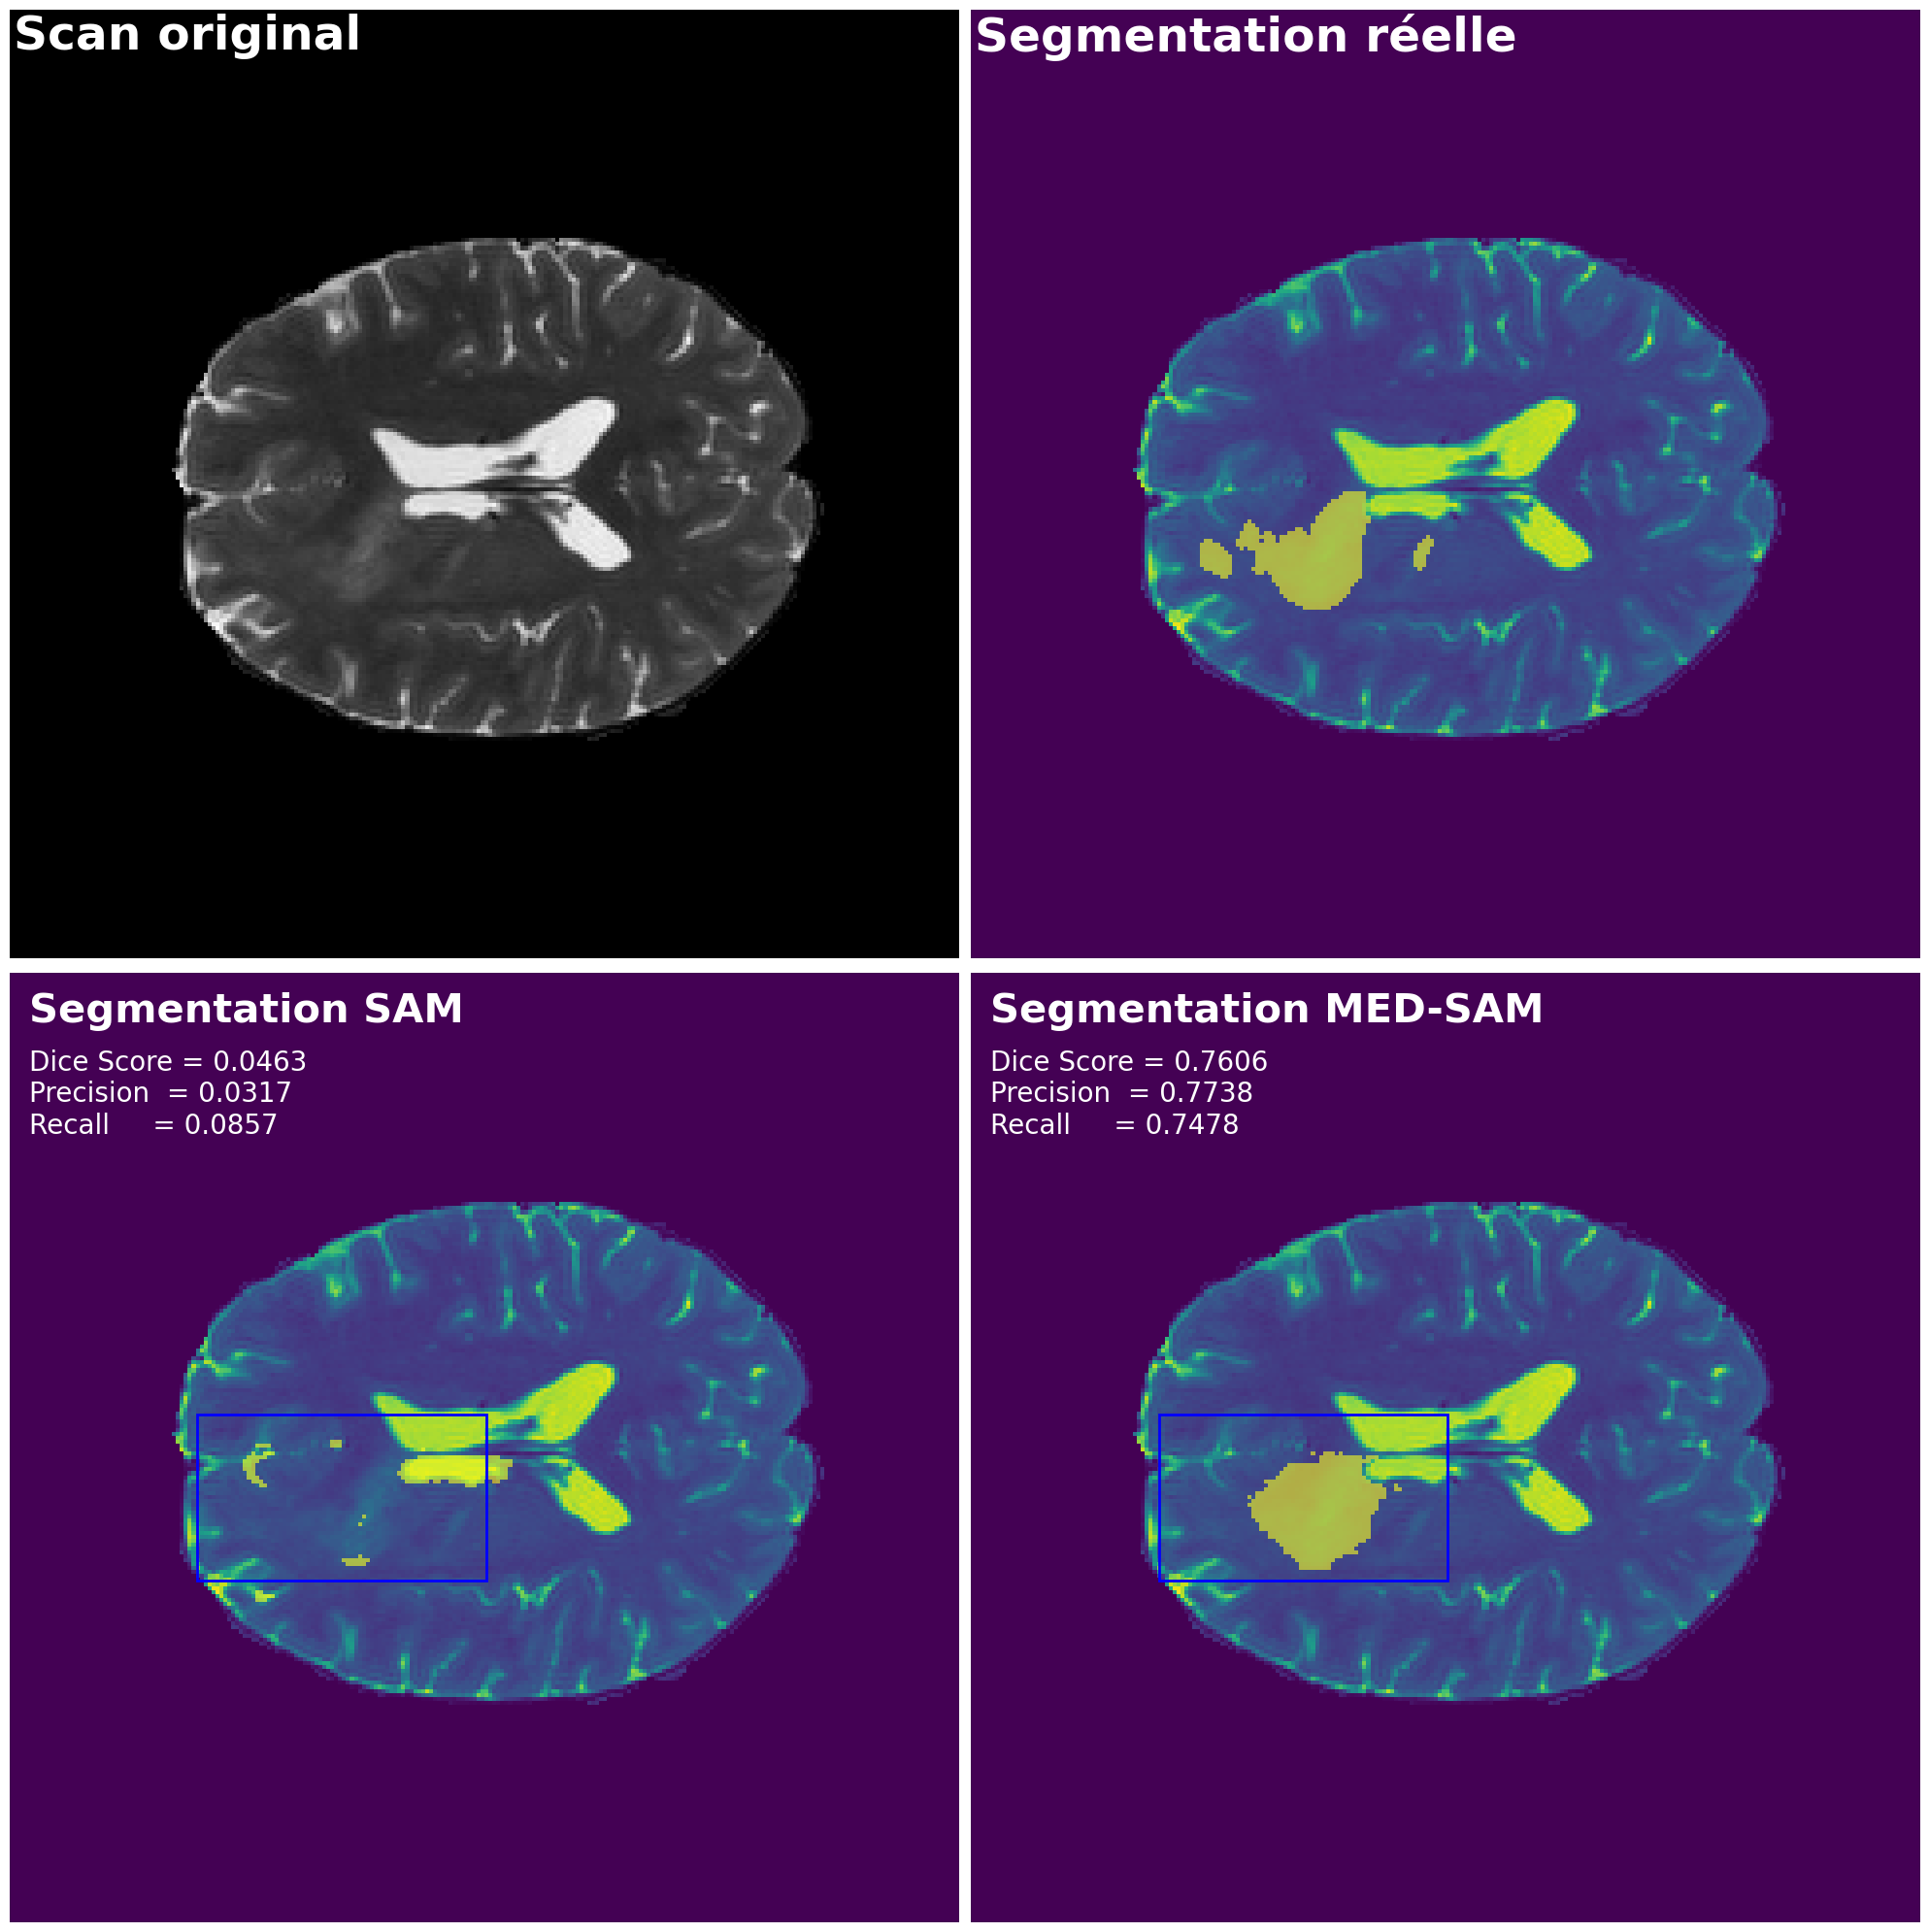

In [19]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='blue', facecolor=(0,0,0,0), lw=2))

fig, axs = plt.subplots(2, 2, figsize=(20, 20))

# Scan original
axs[0, 0].imshow(scan_2d_pre, cmap='gray')
axs[0, 0].axis('off')
axs[0, 0].text(0.5, 0.5, 'Scan original', fontsize=35, fontweight='bold', horizontalalignment='left', verticalalignment='top', color='white')

# Scan + GT
axs[0, 1].imshow(scan_2d_pre)
show_mask(gt_2d > 0, axs[0, 1])        
axs[0, 1].axis('off')
axs[0, 1].text(0.5, 0.5, 'Segmentation réelle', fontsize=35, fontweight='bold', horizontalalignment='left', verticalalignment='top', color='white')

# SAM seg
axs[1, 0].imshow(scan_2d_pre)             
show_mask(sam_seg, axs[1, 0])     
show_box(gt_box, axs[1, 0])
# Titre 
axs[1, 0].text(0.02, 0.98, 'Segmentation SAM', 
               fontsize=30, fontweight='bold',
               horizontalalignment='left', verticalalignment='top', 
               color='white', transform=axs[1, 0].transAxes)

# Métriques 
metrics_text = (
    f'Dice Score = {sam_dsc:.4f}\n'
    f'Precision  = {precision_sam:.4f}\n'
    f'Recall     = {recall_sam:.4f}'
)
axs[1, 0].text(0.02, 0.92, metrics_text, 
               fontsize=20,
               horizontalalignment='left', verticalalignment='top', 
               color='white', transform=axs[1, 0].transAxes)

axs[1, 0].axis('off')


# MedSAM seg
axs[1, 1].imshow(scan_2d_pre)            
show_mask(medsam_seg, axs[1, 1])     
show_box(gt_box, axs[1, 1])
# Titre (grand)
axs[1, 1].text(0.02, 0.98, 'Segmentation MED-SAM', 
               fontsize=30, fontweight='bold',
               horizontalalignment='left', verticalalignment='top', 
               color='white', transform=axs[1, 1].transAxes)

# Métriques 
metrics_text = (
    f'Dice Score = {medsam_dsc:.4f}\n'
    f'Precision  = {precision_medsam:.4f}\n'
    f'Recall     = {recall_medsam:.4f}'
)
axs[1, 1].text(0.02, 0.92, metrics_text, 
               fontsize=20,
               horizontalalignment='left', verticalalignment='top', 
               color='white', transform=axs[1, 1].transAxes)

axs[1, 1].axis('off')

fig.tight_layout()

